In [2]:
import pyomo.environ as pyo
from pyomo.environ import *
from pyomo.contrib.piecewise import PiecewiseLinearFunction
from pyomo.opt import SolverFactory
from pyomo.core.base import TransformationFactory
from pyomo.opt import SolverStatus, TerminationCondition
from dataclasses import dataclass, field
from typing import Callable, List, Dict, Tuple
import numpy as np
import math
import matplotlib.pyplot as plt
import bisect
import itertools as it
from tqdm import tqdm   # 先 import
#from pyomo.environ import ConcreteModel, Var, Constraint, Expression

def evaluate_Q_at(model, first_stg_vars, first_stg_vals, solver):
    """
    Given y = y_val , minimize obj_expr and return v(y).
    This function temporarily increments the objective and clears it after completion, without changing the model structure.
    """
    # Clear any remaining As/pw/obj (to prevent it from being left over from the previous round)
    del_components(model)
    
    for u, v in zip(first_stg_vars, first_stg_vals):
        u.fix(value(v))
    model.obj = Objective(expr=model.obj_expr, sense=minimize)
    results = solver.solve(model, tee=False)

    status_ok = (results.solver.status == SolverStatus.ok)
    term_ok = (results.solver.termination_condition == TerminationCondition.optimal)
    if not (status_ok and term_ok):
        # check if solution okay
        raise RuntimeError(f"Scenario evaluate at y={first_stg_vals} not optimal: "
                           f"status={results.solver.status}, term={results.solver.termination_condition}")

    v_opt = value(model.obj_expr)
    # clear temporarily objective
    model.del_component('obj')
    for u in first_stg_vars:
        u.unfix()
    return v_opt

def _fmt_item(x, prec=6):
    if isinstance(x, (tuple, list)):
        return "(" + ", ".join(f"{float(v):.{prec}f}" for v in x) + ")"
    try:
        return f"{float(x):.{prec}f}"
    except Exception:
        return str(x)

def print_nodes_row(existing_nodes, new_node,
                    existing_values=None, new_value=None,
                    prec_node=2, prec_value=6, pad=2, label_new="(new node)",
                    highlight_min=True):
    """打印节点与值表，最小值高亮红色"""

    headers = [f"node{i+1}" for i in range(len(existing_nodes))] + [f"node{len(existing_nodes)+1} {label_new}"]
    node_strs = [_fmt_item(n, prec_node) for n in existing_nodes] + [_fmt_item(new_node, prec_node)]

    have_vals = existing_values is not None or new_value is not None
    if existing_values is None:
        existing_values = [None] * len(existing_nodes)

    val_strs = []
    if have_vals:
        for v in existing_values:
            val_strs.append(_fmt_item(v, prec_value) if v is not None else "")
        val_strs.append(_fmt_item(new_value, prec_value) if new_value is not None else "")

    # 找到最小值
    min_val = None
    if have_vals and highlight_min:
        try:
            nums = [float(v) for v in existing_values if v is not None]
            if new_value is not None:
                nums.append(float(new_value))
            if nums:
                min_val = min(nums)
        except Exception:
            pass

    # 计算列宽
    cols = max(len(headers), len(node_strs))
    widths = []
    for j in range(cols):
        pieces = []
        if j < len(headers):   pieces.append(headers[j])
        if j < len(node_strs): pieces.append(node_strs[j])
        if have_vals and j < len(val_strs): pieces.append(val_strs[j])
        w = max(len(s) for s in pieces) + pad*2
        widths.append(w)

    def _center(s, w): return s.center(w)
    def _right(s, w):  return s.rjust(w)

    header_line = "".join(_center(h, widths[i]) for i, h in enumerate(headers))
    sep_line = "".join("-" * widths[i] for i in range(len(headers)))
    print(header_line)
    print(sep_line)

    node_line = "".join(_right(s, widths[i]) for i, s in enumerate(node_strs))
    print(node_line)

    if have_vals:
        # 给最小值上色
        val_line_parts = []
        for i, s in enumerate(val_strs):
            if s and min_val is not None and abs(float(s) - min_val) < 1e-12:
                colored = f"\033[31m{s}\033[0m"  # 红色
                val_line_parts.append(_right(colored, widths[i] + 9))  # 留点额外空间
            else:
                val_line_parts.append(_right(s, widths[i]))
        print("".join(val_line_parts))

def del_components(model):
    for comp in ['obj', 'As', 'pw', 'pw_fun', 'pw_As', 'pw_link']:
        if hasattr(model, comp):
            model.del_component(comp)

def corners_from_bounds(firt_stg_vars):
    """给一组 Pyomo Var 生成所有 box 角点（每维取 lb/ub）"""
    bounds = []
    for y in firt_stg_vars:
        lb, ub = y.lb, y.ub
        if lb is None or ub is None:
            raise ValueError(f"{y.name} 缺少上下界，无法生成角点")
        bounds.append((float(lb), float(ub)))
    # 每维挑 lb/ub 的笛卡尔积
    return list(it.product(*[(lb, ub) for (lb, ub) in bounds]))

def add_nd_piecewise(
    model,
    firt_stg_vars,                 # [x1, x2, ..., xN]  模型里的 first stage Var
    points,                 # [(c11,...,c1N), (c21,...,c2N), ...]  所有节点（同维度 N）
    values,                 # 与 points 对齐的一维 list/array，或 dict{point_tuple: value}
    name="pw",
    relation="==",          # '==', '>='(下界/内逼近), '<='(上界/外逼近)
    round_ndigits=12,       # 为避免浮点比较问题，对坐标做轻微 round
):
    """
    返回 (z, pw)。z 是 Var（或你可将 make_z_var=False 改成返回 Expression）。
    """

    # 维度检查
    if len(points) == 0:
        raise ValueError("points 不能为空")
    N = len(firt_stg_vars)
    for pt in points:
        if len(pt) != N:
            raise ValueError(f"points 中出现与 x_vars 维度不一致的点: {pt}")
        
    del_components(model)

    # 统一坐标的浮点表示，避免查表时精度问题
    def keyize(coords):
        return tuple(round(float(c), round_ndigits) for c in coords)

    norm_points = [keyize(pt) for pt in points]

    # 把 values 统一成 dict 表
    if isinstance(values, dict):
        table = {keyize(k): float(v) for k, v in values.items()}
        # 确保每个 point 都有值
        miss = [pt for pt in norm_points if pt not in table]
        if miss:
            raise KeyError(f"values 缺少这些点的取值: {miss[:5]}{' ...' if len(miss)>5 else ''}")
    else:
        # 视作与 points 对齐的一维序列
        if len(values) != len(points):
            raise ValueError("values 长度应与 points 数量一致（或传 dict）")
        table = {pt: float(v) for pt, v in zip(norm_points, values)}

    # 查表函数（仅在节点上被调用）
    def _f_from_table(*coords):
        return table[keyize(coords)]

    # 创建并挂到模型
    pw = PiecewiseLinearFunction(points=norm_points, function=_f_from_table, name=f"{name}_fun")
    model.add_component(pw.name, pw)

    # 组成表达式
    pw_expr = pw(*firt_stg_vars)

    As = Var(name=f"{name}_As")
    model.add_component(As.name, As)
    if relation == "==":
        link = Constraint(expr=As == pw_expr)
    elif relation == ">=":
        link = Constraint(expr=As >= pw_expr)
    elif relation == "<=":
        link = Constraint(expr=As <= pw_expr)
    else:
        raise ValueError("relation 只能是 '==', '>=', '<='")
    model.add_component(f"{name}_link", link)

    TransformationFactory('contrib.piecewise.convex_combination').apply_to(model)
        
    return As, pw

def clone_and_get_vars(m_old, first_stage_vars):
    """
    克隆模型，并按名字列表返回新模型中的变量组件
    var_names: ['y', 'x', ...]  (只能是容器名，不是元素)
    """
    m_new = m_old.clone()
    first_stage_vars_new = []
    for v in first_stage_vars:
        v_new = m_new.find_component(v.name)
        if v_new is None:
            raise KeyError(f"在新模型里找不到变量 '{v.name}'")
        first_stage_vars_new.append(v_new)
    return m_new, first_stage_vars_new

# delete repeated nodes
def unique_points(points, atol=1e-9):
    out = []
    for p in points:
        if not any(all(abs(a-b) <= atol for a,b in zip(p, q)) for q in out):
            out.append(p)
    return out

# underestimator code
def nc_underest(model_list, first_stg_vars_list, m_tmpl_list, target_nodes,
                picture_shown=False, v_list=False, tolerance=1e-8, probs=None):
    N = len(model_list)
    if probs is None:
        probs = [1.0]*N
    assert len(probs) == N

    # -------- 追踪容器（新增） --------
    UB_hist, LB_hist, GAP_hist, Ybest_hist = [], [], [], []

    UB_best = float('inf')
    y_best  = None
    as_nodes_list = [[] for _ in range(N)]
    ms_list = [None] * N
    new_nodes_list = [None] * N  # Storing potential new nodes
    As_min_list = []
    under_tol = 1e-8
    add_node_history = []

    # set up solver
    solver = SolverFactory('gurobi')
    solver.options.update({
        'MIPGap': 1e-3,
        'FeasibilityTol': 1e-6,
        'IntFeasTol':     1e-6,
        'OptimalityTol':  1e-6,
        'NumericFocus':   1,
        'Presolve':       2,
        'NonConvex':      2,
        'MIPFocus':       1,
    })

    # start from corner nodes
    first_stg_nodes = corners_from_bounds(first_stg_vars_list[0])
    for i in range(N):
        p_i = probs[i]
        as_nodes_list[i].extend(
            p_i * evaluate_Q_at(model_list[i], first_stg_vars_list[i], node, solver)
            for node in first_stg_nodes
        )

    # 初始化 UB：对所有角点算加权真值并取最小
    for y0 in first_stg_nodes:
        Qy = 0.0
        for i in range(N):
            Qy += probs[i] * evaluate_Q_at(model_list[i], first_stg_vars_list[i], y0, solver)
        if Qy < UB_best:
            UB_best, y_best = Qy, y0

    # ------- 计算初始 LB（在角点上建立 As_sum）并记录第0轮 --------
    arr0 = np.array(as_nodes_list, dtype=float, ndmin=2)
    assum_nodes0 = arr0.sum(axis=0)

    model_sum0, model_sum_first_stg_vars0 = clone_and_get_vars(m_tmpl_list[0], m_tmpl_list[1])
    del_components(model_sum0)
    As0, _ = add_nd_piecewise(
        model_sum0, model_sum_first_stg_vars0, first_stg_nodes, assum_nodes0,
        name="pw", relation="=="
    )
    model_sum0.obj = Objective(expr=As0, sense=minimize)
    res0 = solver.solve(model_sum0, tee=False)

    # 计算 init 的 ms，使 LB0 与后续一致
    ms0 = []
    for i in range(N):
        del_components(model_list[i])
        As_i, _ = add_nd_piecewise(model_list[i], first_stg_vars_list[i],
                                first_stg_nodes, as_nodes_list[i],
                                name="pw", relation="==")
        model_list[i].obj = Objective(expr=probs[i]*model_list[i].obj_expr - As_i, sense=minimize)
        r_i = solver.solve(model_list[i], tee=False)
        ms0.append(value(model_list[i].obj))
    LB0 = res0.problem.lower_bound + sum(ms0)   # 用相同公式



    if (res0.solver.status == SolverStatus.ok) and (res0.solver.termination_condition == TerminationCondition.optimal):
        LB0 = res0.problem.lower_bound  # 初始不加 ms（此时 ms 未定义或为 0）
    else:
        LB0 = float('-inf')

    UB_hist.append(float(UB_best))
    LB_hist.append(float(LB0))
    GAP_hist.append((UB_hist[-1] - LB_hist[-1]) / max(1.0, abs(UB_hist[-1])))
    Ybest_hist.append(tuple(y_best) if y_best is not None else None)

    print(f"[INIT] LB={LB0:.6f}, UB*={UB_best:.6f}, GAP={GAP_hist[-1]:.2%}, y*={y_best}")

    if target_nodes <= len(first_stg_nodes):
        print('target_nodes number should be larger than ', len(first_stg_nodes))
        return

    print('Start from ', len(first_stg_nodes), ' corner nodes')
    print('The goal is to get ', target_nodes, ' nodes')
    k_list = []

    for k in tqdm(range(len(first_stg_nodes)+1, target_nodes+1), desc="Adding nodes"):
        print('##################################################')
        print('##################################################')
        print('Start adding node ', k)
        k_list.append(k)
        for i in range(N):
            print('\nSolving scenario ', i)
            # define piecewise function for each scenario
            del_components(model_list[i])

            # start solving sceanario
            p_i = probs[i]
            As, _ = add_nd_piecewise(model_list[i], first_stg_vars_list[i],
                                     first_stg_nodes, as_nodes_list[i], name="pw", relation="==")
            model_list[i].obj = Objective(expr=p_i*model_list[i].obj_expr - As, sense=minimize)
            results = solver.solve(model_list[i], tee=False)
            if (results.solver.status != SolverStatus.ok) or \
               (results.solver.termination_condition != TerminationCondition.optimal):
                print("⚠ There may be problems with the solution")
            ms_list[i] = value(model_list[i].obj)
            new_nodes_list[i] = tuple(value(v) for v in first_stg_vars_list[i])
            print('new node is ', tuple(value(v) for v in first_stg_vars_list[i]))
            print('ms is ', value(model_list[i].obj))

        # define and solve the sum model to check if error at possible new node is too big
        arr = np.array(as_nodes_list, dtype=float, ndmin=2)
        assum_nodes = arr.sum(axis=0)

        print('XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX')
        print(first_stg_nodes)
        print(assum_nodes)

        # build As_sum model and solve for possible node pf max error
        model_sum, model_sum_first_stg_vars = clone_and_get_vars(m_tmpl_list[0], m_tmpl_list[1])
        del_components(model_sum)
        As, pw = add_nd_piecewise(
            model_sum, model_sum_first_stg_vars, first_stg_nodes, assum_nodes,
            name="pw", relation="=="
        )
        model_sum.obj = Objective(expr=As, sense=minimize)
        results = solver.solve(model_sum, tee=False)
        if not ((results.solver.status == SolverStatus.ok) and
                (results.solver.termination_condition == TerminationCondition.optimal)):
            print("Sum model doesn't get solved normally")

        # get the output
        As_min = results.problem.lower_bound
        print(f'As_min at possible new node is {As_min}')
        node_star = tuple(value(v) for v in model_sum_first_stg_vars)

        if (node_star is None) or (node_star in first_stg_nodes):
            avg = []
            for j in range(len(first_stg_nodes[0])):
                comp_vals = [node[j] for node in first_stg_nodes]
                avg.append(sum(comp_vals) / len(comp_vals))
            node_star = tuple(avg)
            As_min = value(pw(*node_star))

        q_node_star = 0.0
        for i in range(N):
            q_node_star += probs[i] * evaluate_Q_at(model_list[i], first_stg_vars_list[i], node_star, solver)

        print(f'Real value at possible new node is {q_node_star}')
        errors_node_star = abs(As_min - q_node_star)
        print(f'error at possible new node is {errors_node_star}')

        sum_ms = sum(ms_i for ms_i in ms_list)

        print('Sum *****************************************')
        print('error at y_star is ', errors_node_star)
        print('y_star is ', node_star)
        print('ms_list and sum_ms is ', ms_list, sum_ms)
        if errors_node_star > abs(sum_ms):
            new_node = node_star
            print('new node choosen from error')
        else:
            min_index = int(np.argmin(ms_list))
            new_node = new_nodes_list[min_index]
            print('new node choosen from ms')

        # ------ 本轮 LB 记作 As_min + sum_ms（你的原逻辑），并记录 ------
        LB_k = As_min + sum_ms
        As_min_list.append(LB_k)
        add_node_history.append(new_node)

        print_nodes_row(first_stg_nodes, new_node,
                        existing_values=assum_nodes,
                        new_value=q_node_star,
                        prec_node=1,
                        prec_value=6)
        print('new node is', new_node)
        print('Current As_min (LB candidate) is', As_min_list[-1])
        print('*****************************************\n')

        # 更新节点与 as_nodes
        print('current nodes are ', first_stg_nodes)
        print('as_nodes_list are ', as_nodes_list)
        print('new_node is', new_node)
        first_stg_nodes.append(new_node)
        for i in range(N):
            as_nodes_list[i].append(probs[i] * evaluate_Q_at(model_list[i], first_stg_vars_list[i], new_node, solver))

        # 评估新节点上界候选并更新最优 UB
        Q_new = 0.0
        for i in range(N):
            Q_new += probs[i] * evaluate_Q_at(model_list[i], first_stg_vars_list[i], new_node, solver)
        if Q_new < UB_best:
            UB_best, y_best = Q_new, new_node

        # ------ 记录历史（本轮）------
        UB_hist.append(float(UB_best))
        LB_hist.append(float(LB_k))
        GAP_hist.append((UB_hist[-1] - LB_hist[-1]) / max(1.0, abs(UB_hist[-1])))
        Ybest_hist.append(tuple(y_best))

        print(f"[PROGRESS] LB={LB_hist[-1]:.6f}, UB*={UB_hist[-1]:.6f}, GAP={GAP_hist[-1]:.2%}, y*={y_best}")

        # 小红字：当前聚合 As 的最小值位置
        arr = np.array(as_nodes_list, dtype=float, ndmin=2)
        assum_nodes = arr.sum(axis=0)
        idx = int(np.argmin(assum_nodes))
        val = assum_nodes[idx]
        print(f"\033[31mcurrent node is {idx+1} node, value is {val:.6f}\033[0m")
        print(f"node is{first_stg_nodes[idx]}")

    # define and solve the final sum model
    arr = np.array(as_nodes_list, dtype=float, ndmin=2)
    assum_nodes = arr.sum(axis=0)

    model_sum, model_sum_first_stg_vars = clone_and_get_vars(m_tmpl_list[0], m_tmpl_list[1])
    del_components(model_sum)
    As, _ = add_nd_piecewise(
        model_sum, model_sum_first_stg_vars, first_stg_nodes, assum_nodes,
        name="pw", relation="=="
    )
    model_sum.obj = Objective(expr=As, sense=minimize)
    results = solver.solve(model_sum, tee=False)
    if not ((results.solver.status == SolverStatus.ok) and
            (results.solver.termination_condition == TerminationCondition.optimal)):
        print("Sum model doesn't get solved normally")

    output_lb = results.problem.lower_bound + sum(ms_list)
    print('lower bound is ', output_lb)
    print('node is ', tuple(value(v) for v in model_sum_first_stg_vars))
    print('best UB (weighted true) is ', UB_best, ', at y* = ', y_best)

    # ------ 收尾：把最终一行也补到历史（若未覆盖）------
    if len(LB_hist) < len(UB_hist):  # 正常不会触发，仅防御
        LB_hist.append(float(output_lb))
        GAP_hist.append((UB_hist[-1] - LB_hist[-1]) / max(1.0, abs(UB_hist[-1])))
        Ybest_hist.append(tuple(y_best))

    # ------ 打印对比表 ------
    print("\n==== UB / LB per iteration ====")
    print("iter\tLB\t\tUB*\t\tgap\t\ty*")
    for it in range(len(UB_hist)):
        lb = LB_hist[it]
        ub = UB_hist[it]
        gap = GAP_hist[it]
        yb = Ybest_hist[it]
        print(f"{it:02d}\t{lb:.6f}\t{ub:.6f}\t{gap:.2%}\t{yb}")

    # 返回历史，便于外部保存或画图
    history = {
        "UB": UB_hist,          # len = 1 + 迭代轮数（含 INIT）
        "LB": LB_hist,
        "gap": GAP_hist,
        "y_best": Ybest_hist    # 每一轮的最优 y*
    }

    return output_lb, first_stg_nodes, [k_list, As_min_list, add_node_history], history


##################################################################################################################
##################################################################################################################
##################################################################################################################

def build_pid_model(
    T=10,                 # 时间步数
    h=0.2,                # 步长 Δt
    scen=None,            # 单个场景数据: {"Ku":..., "tau":..., "d":[...], "sp":[...]}
    weights=(1.0, 0.01),  # 目标权重 (w_e, w_u)
    bounds={"x":(-20,20), "u":(-20,20), "Kp":(0,100), "Ki":(0,100), "Kd":(0,100)},
    use_cvar=False,       # 保留参数，但单场景下一般不需要
    alpha=0.95
):
    """
    单场景 PID 控制模型:
      tau * x_dot + x = Ku * u + d
      u = Kp*e + Ki*I + Kd*de/dt,   e = sp - x,   I_dot = e
    离散化: 隐式欧拉
    """
    assert scen is not None, "请提供一个场景字典"

    Ku, tau, d, sp = scen["Ku"], scen["tau"], scen["d"], scen["sp"]

    m = pyo.ConcreteModel()
    m.T = pyo.RangeSet(0, T)
    m.Tm = pyo.RangeSet(1, T)

    # 一阶段变量 (PID 参数)
    m.Kp = pyo.Var(bounds=bounds["Kp"])
    m.Ki = pyo.Var(bounds=bounds["Ki"])

    # 二阶段变量
    m.x = pyo.Var(m.T, bounds=bounds["x"])
    m.u = pyo.Var(m.T, bounds=bounds["u"])
    m.e = pyo.Var(m.T, bounds=bounds["e"])
    m.I = pyo.Var(m.T, bounds=bounds["I"])


    # 误差 e_t = sp_t - x_t
    def _err_rule(m, t): return m.e[t] == sp[t] - m.x[t]
    m.err_def = pyo.Constraint(m.T, rule=_err_rule)

    # I 动态
    def _I_dyn(m, t): return m.I[t] == m.I[t-1] + h*m.e[t]
    m.I_dyn = pyo.Constraint(m.Tm, rule=_I_dyn)

    # 系统动态 (隐式欧拉)
    def _x_dyn(m, t):
        return m.x[t] == m.x[t-1] + (h/tau)*(-m.x[t] + Ku*m.u[t] + d[t])
    m.x_dyn = pyo.Constraint(m.Tm, rule=_x_dyn)

    # PID 控制律
    def _pid_rule(m, t):
        if t == 0:
            return m.u[t] == m.Kp*m.e[t] + m.Ki*m.I[t]
        return m.u[t] == m.Kp*m.e[t] + m.Ki*m.I[t] 
    m.pid = pyo.Constraint(m.T, rule=_pid_rule)

    # 初值
    m.x0 = pyo.Constraint(expr=m.x[0] == 0)
    m.I0 = pyo.Constraint(expr=m.I[0] == 0)

    # 成本函数 (单场景就是一个值)
    w_e, w_u = weights
    m.cost = pyo.Expression(expr=sum(
        h*(w_e*m.e[t]**2 + w_u*m.u[t]**2) for t in m.T
    ))

    # 目标: 单场景情况下就直接最小化 cost
    #m.obj = pyo.Objective(expr=m.cost, sense=pyo.minimize)
    m.obj_expr = pyo.Expression(expr = m.cost)

    return m,  [m.Kp, m.Ki]


if __name__ == '__main__':
    T, h = 10, 0.2
    times = [t for t in range(T+1)]

    def step_sp(t): return 1.0 if t*h >= 0.5 else 0.0
    #def make_d(amp): return [amp*math.sin(0.5*t*h) for t in times]
    def make_d(amp, bias=0.1): 
        return [bias + amp*math.sin(0.5*t*h) for t in times]

    scenarios = {
        1: {"prob": 0.4, "Ku": 3.0, "tau": 2.0, "d": make_d(0.2), "sp": [step_sp(t) for t in times]},
    }
    '''scenarios = {
        1: {"prob": 0.4, "Ku": 3.0, "tau": 2.0, "d": make_d(0.2), "sp": [step_sp(t) for t in times]},
        2: {"prob": 0.4, "Ku": 2.7, "tau": 1.8, "d": make_d(0.5), "sp": [step_sp(t) for t in times]},
        3: {"prob": 0.4, "Ku": 3.3, "tau": 2.2, "d": make_d(0.8), "sp": [step_sp(t) for t in times]},
    }'''
    probs = [sc.get("prob", 1.0) for _, sc in scenarios.items()]
    model_list = []
    first_stg_vars_list = []
    I_max = 1.5 * T*h*21  
    #bounds={"x":(-20,20), "u":(-20,20), "e":(-21,21), "I":(-I_max,I_max), "Kp":(0,100), "Ki":(0,100), "Kd":(0,100)}
    bounds={"x":(-20,20), "u":(-20,20), "e":(-21,21), "I":(-I_max,I_max), "Kp":(0,50), "Ki":(0,100), "Kd":(0,50)}
    for _, scen in scenarios.items():
        m, m_f_stg_vars = build_pid_model(T=T, h=h, scen=scen, weights=(1.0, 0.09), bounds=bounds)
        model_list.append(m)
        first_stg_vars_list.append(m_f_stg_vars)
    m_tmpl = pyo.ConcreteModel()
    m_tmpl.T = pyo.RangeSet(0, T)
    m_tmpl.Tm = pyo.RangeSet(1, T)
    m_tmpl.Kp = pyo.Var(bounds=bounds["Kp"])
    m_tmpl.Ki = pyo.Var(bounds=bounds["Ki"])
    m_tmpl_list = [m_tmpl, [m_tmpl.Kp, m_tmpl.Ki]]


    # 为每个模型各自创建一个 persistent 实例（也可复用一个实例按需 set_instance）
    opts = {
        'MIPGap': 1e-2,       # 先用 1% 提速外层；收尾再收紧
        'FeasibilityTol': 1e-6,
        'IntFeasTol':     1e-6,
        'OptimalityTol':  1e-6,
        'NumericFocus':   1,
        'Presolve':       2,
        'NonConvex':      2,  # 你有双线性
        'MIPFocus':       1,
        # 可选：'TimeLimit': 10
    }

    persistent_solvers = []
    for m in model_list:
        opt = SolverFactory("gurobi_persistent")
        opt.set_instance(m)
        for k, v in opts.items():
            opt.set_gurobi_param(k, v)
        persistent_solvers.append(opt)

    # 给每个场景准备一份温启动“解的存档”
    warm_solutions = [None for _ in model_list]

    out_lb, nodes, aux, hist = nc_underest(model_list, first_stg_vars_list, m_tmpl_list,
                                        target_nodes=30, picture_shown=False, v_list=False,
                                        tolerance=1e-8, probs=probs)

    # 打印或保存
    print(hist["UB"])
    print(hist["LB"])

Set parameter MIPGap to value 0.01
Set parameter FeasibilityTol to value 1e-06
Set parameter IntFeasTol to value 1e-06
Set parameter OptimalityTol to value 1e-06
Set parameter NumericFocus to value 1
Set parameter Presolve to value 2
Set parameter NonConvex to value 2
Set parameter MIPFocus to value 1
[INIT] LB=0.080913, UB*=0.080913, GAP=0.00%, y*=(0.0, 100.0)
Start from  4  corner nodes
The goal is to get  30  nodes


Adding nodes:   0%|          | 0/26 [00:00<?, ?it/s]

##################################################
##################################################
Start adding node  5

Solving scenario  0
new node is  (2.2619209702105136, 3.0997337803367735)
ms is  -0.4500008535078489
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
[(0.0, 0.0), (0.0, 100.0), (50.0, 0.0), (50.0, 100.0)]
[0.53941384 0.08091284 0.0862691  0.08933289]
As_min at possible new node is 0.08091283529414117
Real value at possible new node is 0.0831570325157251
error at possible new node is 0.23121633404375636
Sum *****************************************
error at y_star is  0.23121633404375636
y_star is  (25.0, 50.0)
ms_list and sum_ms is  [-0.4500008535078489] -0.4500008535078489
new node choosen from ms
    node1          node2           node3           node4        node5 (new node)  
----------------------------------------------------------------------------------
    (0.0, 0.0)    (0.0, 100.0)    (50.0, 0.0)    (50.0, 100.0)          (2.3, 3.1)
      0.539414        0.

Adding nodes:   4%|▍         | 1/26 [00:04<01:44,  4.20s/it]

[PROGRESS] LB=-0.135627, UB*=0.069008, GAP=20.46%, y*=(2.2619209702105136, 3.0997337803367735)
current node is 5 node, value is 0.069008
node is(2.2619209702105136, 3.0997337803367735)
##################################################
##################################################
Start adding node  6

Solving scenario  0
new node is  (3.056873241273628, 0.0)
ms is  -0.44361707575899584
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
[(0.0, 0.0), (0.0, 100.0), (50.0, 0.0), (50.0, 100.0), (2.2619209702105136, 3.0997337803367735)]
[0.53941384 0.08091284 0.0862691  0.08933289 0.06900845]
As_min at possible new node is 0.06900845140097439
Real value at possible new node is 0.06900845140097003
error at possible new node is 4.3576253716537394e-15
Sum *****************************************
error at y_star is  4.3576253716537394e-15
y_star is  (2.261920970211, 3.099733780337)
ms_list and sum_ms is  [-0.44361707575899584] -0.44361707575899584
new node choosen from ms
    node1          no

...

[PROGRESS] LB=0.027997, UB*=0.064330, GAP=3.63%, y*=(4.514166250955805, 8.443182862042024)
current node is 15 node, value is 0.064330
node is(4.514166250955805, 8.443182862042024)
##################################################
##################################################
Start adding node  30

Solving scenario  0
new node is  (0.34352936863862027, 0.2908085705326928)
ms is  -0.017647372870398165
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
[(0.0, 0.0), (0.0, 100.0), (50.0, 0.0), (50.0, 100.0), (2.2619209702105136, 3.0997337803367735), (3.056873241273628, 0.0), (0.0, 9.28112215458857), (0.19750413821564716, 1.1655589897353242), (0.0, 1.3236100479037378), (0.8403158031723297, 0.0), (0.07652007761996028, 0.45157871207550954), (0.0, 0.5275286992080094), (0.3371524029610596, 0.0), (0.7869328440335905, 1.9415007843573124), (4.514166250955805, 8.443182862042024), (0.034791370578710255, 0.20531921563532796), (1.6457903445805513, 0.0), (0.0, 0.2422712314019894), (0.15343897607010798,

Adding nodes: 100%|██████████| 26/26 [16:30<00:00, 58.33s/it]

[PROGRESS] LB=0.046683, UB*=0.064330, GAP=1.76%, y*=(4.514166250955805, 8.443182862042024)
current node is 15 node, value is 0.064330
node is(4.514166250955805, 8.443182862042024)


Adding nodes: 100%|██████████| 26/26 [16:30<00:00, 38.09s/it]


lower bound is  0.04668273877519327
node is  (4.514166250956, 8.443182862042)
best UB (weighted true) is  0.06433011164559144 , at y* =  (4.514166250955805, 8.443182862042024)

==== UB / LB per iteration ====
iter	LB		UB*		gap		y*
00	0.080913	0.080913	0.00%	(0.0, 100.0)
01	-0.135627	0.069008	20.46%	(2.2619209702105136, 3.0997337803367735)
02	-0.374609	0.068093	44.27%	(3.056873241273628, 0.0)
03	-0.323220	0.068093	39.13%	(3.056873241273628, 0.0)
04	-0.218688	0.068093	28.68%	(3.056873241273628, 0.0)
05	-0.215259	0.068093	28.34%	(3.056873241273628, 0.0)
06	-0.172765	0.068093	24.09%	(3.056873241273628, 0.0)
07	-0.044604	0.068093	11.27%	(3.056873241273628, 0.0)
08	-0.039146	0.068093	10.72%	(3.056873241273628, 0.0)
09	-0.018935	0.068093	8.70%	(3.056873241273628, 0.0)
10	0.022857	0.068093	4.52%	(3.056873241273628, 0.0)
11	0.028616	0.064330	3.57%	(4.514166250955805, 8.443182862042024)
12	0.030497	0.064330	3.38%	(4.514166250955805, 8.443182862042024)
13	0.031041	0.064330	3.33%	(4.51416625095580

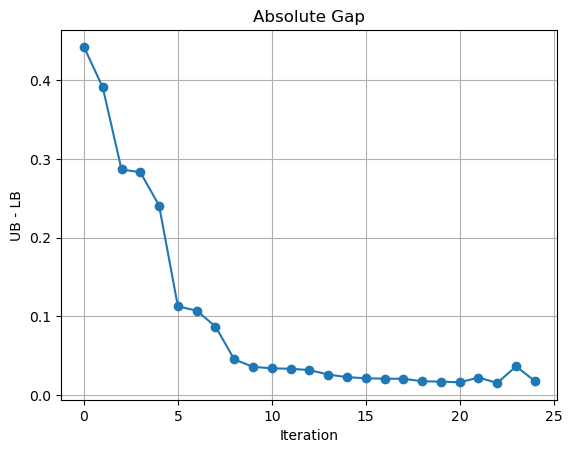

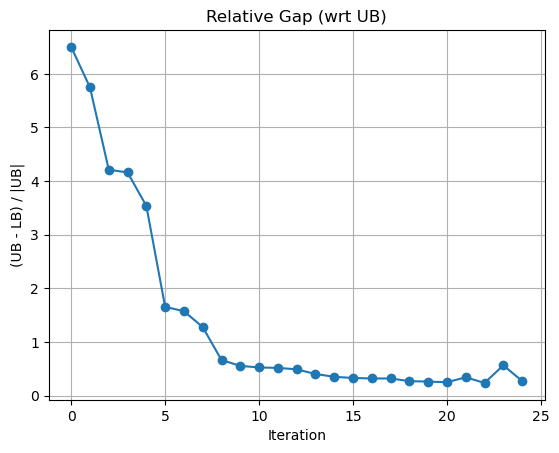

iteration   abs gap        rel gap (%)    
0           0.000000       0.00          %
1           0.204636       296.54        %
2           0.442701       650.15        %
3           0.391312       574.68        %
4           0.286781       421.16        %
5           0.283352       416.13        %
6           0.240858       353.72        %
7           0.112697       165.50        %
8           0.107239       157.49        %
9           0.087028       127.81        %
10          0.045235       66.43         %
11          0.035714       55.52         %
12          0.033833       52.59         %
13          0.033289       51.75         %
14          0.031592       49.11         %
15          0.025983       40.39         %
16          0.022603       35.14         %
17          0.021198       32.95         %
18          0.020606       32.03         %
19          0.020585       32.00         %
20          0.017394       27.04         %
21          0.016904       26.28         %
22         

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

iters = list(range(len(hist["UB"])))
ub_list, lb_list = hist["UB"], hist["LB"]

def compute_and_plot_gaps(ub_list, lb_list, iters, eps=1e-8):
    ub = np.array(ub_list, dtype=float)
    lb = np.array(lb_list, dtype=float)
    abs_gap = ub - lb
    rel_gap = abs_gap / (np.abs(ub) + eps)

    # 画绝对 gap
    plt.figure()
    plt.plot(abs_gap[2:], marker='o')
    plt.title("Absolute Gap")
    plt.xlabel("Iteration")
    plt.ylabel("UB - LB")
    plt.grid(True)
    plt.show()

    # 画相对 gap
    plt.figure()
    plt.plot(rel_gap[2:], marker='o')
    plt.title("Relative Gap (wrt UB)")
    plt.xlabel("Iteration")
    plt.ylabel("(UB - LB) / |UB|")
    plt.grid(True)
    plt.show()

    return abs_gap.tolist(), rel_gap.tolist()

abs_gap, rel_gap = compute_and_plot_gaps(ub_list, lb_list, iters)
def print_gap_table(iters, abs_gap, rel_gap):
    # 打印标题
    print(f"{'iteration':<12}{'abs gap':<15}{'rel gap (%)':<15}")
    # 打印每一行
    for i, (a, r) in zip(iters, zip(abs_gap, rel_gap)):
        print(f"{i:<12d}{a:<15.6f}{r*100:<14.2f}%")

iters = list(range(len(abs_gap)))
print_gap_table(iters, abs_gap, rel_gap)


In [15]:
%pip install pandas


   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ------------ --------------------------- 3.7/11.3 MB 27.3 MB/s eta 0:00:01
   ---------------------------------------  11.3/11.3 MB 32.0 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 29.5 MB/s  0:00:00

   ---------------------------------------- 0/2 [tzdata]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   ---------

In [ ]:
iters = list(range(len(hist["UB"])))
UB, LB = hist["UB"], hist["LB"]

for ub, lb in zip(UB, LB):
    g = (ub - lb) / max(1e-9, abs(ub))
    print(g*100)

gap_abs = 
gap_rel = 
#GAP_hist.append((UB_hist[-1] - LB_hist[-1]) / max(1.0, abs(UB_hist[-1])))

0.0
296.5375025738549
650.1454228365102
574.6763042018223
421.16266939294434
416.12703142980496
353.7208796742409
165.5047757572754
157.49000591267597
127.80804640767778
66.43213959291523
55.5172099723353
52.5924925892556
51.74675547191489
49.10948647854268
40.389632228916334
35.136487794660134
32.95245079075418
32.03176034944008
31.999004193836967
27.038344222680088
26.2766449407709
24.990574821174675
34.262812890496896
23.73584358675191
56.47957465012852
27.43252330669248


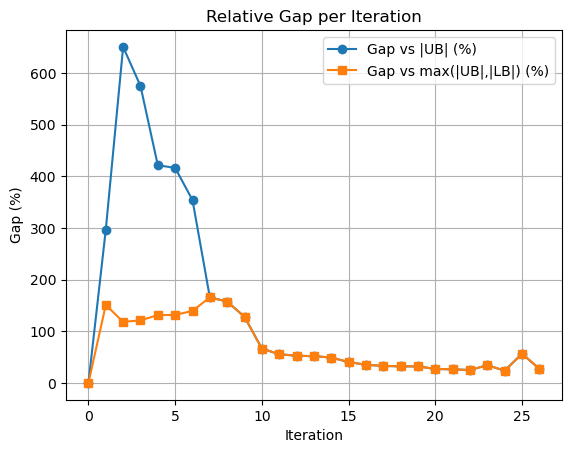

In [3]:
iters = list(range(len(hist["UB"])))
UB, LB = hist["UB"], hist["LB"]

def gap_vs_ub(ub, lb):      # Gurobi风格
    return (ub - lb) / max(1e-9, abs(ub))
def gap_symmetric(ub, lb):  # 相对max(|UB|,|LB|)
    return (ub - lb) / max(1e-9, max(abs(ub), abs(lb)))

gap1 = [gap_vs_ub(u, l)*100 for u, l in zip(UB, LB)]
gap2 = [gap_symmetric(u, l)*100 for u, l in zip(UB, LB)]

import matplotlib.pyplot as plt

plt.figure()
plt.plot(iters, gap1, marker='o', label='Gap vs |UB| (%)')
plt.plot(iters, gap2, marker='s', label='Gap vs max(|UB|,|LB|) (%)')
plt.xlabel('Iteration'); plt.ylabel('Gap (%)')
plt.title('Relative Gap per Iteration')
plt.grid(True); plt.legend()
# 可选：对数刻度观察收敛
# plt.yscale('log')
plt.show()


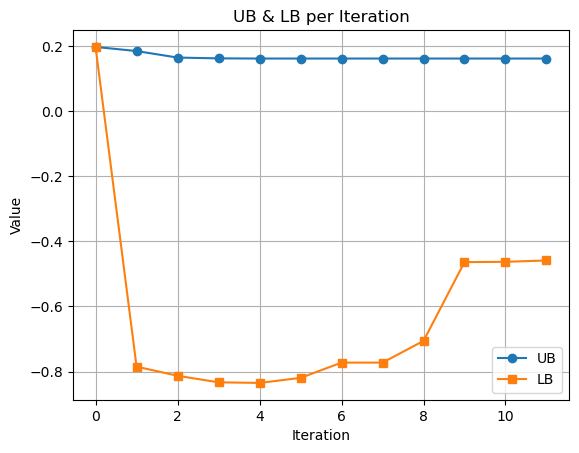

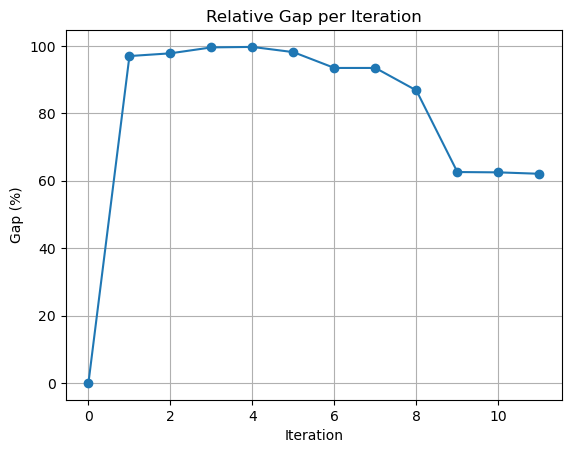

In [5]:
# 1) 整理数据
iters = list(range(len(hist["UB"])))
UB = hist["UB"]
LB = hist["LB"]
gap = [ (ub - lb) / max(1.0, abs(ub)) for ub, lb in zip(UB, LB) ]  # 相对gap

# 2) UB / LB 随迭代
plt.figure()
plt.plot(iters, UB, marker='o', label='UB')
plt.plot(iters, LB, marker='s', label='LB')
plt.xlabel('Iteration')
plt.ylabel('Value')
plt.title('UB & LB per Iteration')
plt.legend()
plt.grid(True)

# 3) GAP(%) 随迭代
plt.figure()
plt.plot(iters, [g*100 for g in gap], marker='o')
plt.xlabel('Iteration')
plt.ylabel('Gap (%)')
plt.title('Relative Gap per Iteration')
plt.grid(True)
plt.show()


In [19]:
solver = pyo.SolverFactory("ipopt")
first_stg_nodes = [(0.0, 0.0, 0.0), (0.0, 0.0, 1000.0), (0.0, 1000.0, 0.0), (0.0, 1000.0, 1000.0), (100.0, 0.0, 0.0), (100.0, 0.0, 1000.0), (100.0, 1000.0, 0.0), (100.0, 1000.0, 1000.0)]
assum_nodes = [4.54023507, 0.05320473, 0.04886529, 0.05321642, 0.04795115, 0.05320593, 0.05042764, 0.05321691]

# build As_sum model and solve for possible node pf max error
model_sum, model_sum_first_stg_vars = clone_and_get_vars(m_tmpl_list[0], m_tmpl_list[1])
del_components(model_sum)
As, pw = add_nd_piecewise(
model_sum, model_sum_first_stg_vars, first_stg_nodes, assum_nodes,
name="pw", relation="=="
)
model_sum.obj = Objective(expr= As, sense=minimize)

#results = SolverFactory("gurobi").solve(model_sum, tee=False)
results = solver.solve(model_sum, tee=False)
if (results.solver.status == SolverStatus.ok) and (results.solver.termination_condition == TerminationCondition.optimal):
    pass
else:
    print("Sum model doesn't get solved normally")

# get the output
As_min = results.problem.lower_bound
print(f'As_min at possible new node is {As_min}')
node_star = tuple(value(v) for v in model_sum_first_stg_vars) 

As_min at possible new node is -inf


In [20]:
print(f'As_min at possible new node is {value(model_sum.obj)}')

As_min at possible new node is 0.04795113247498382
